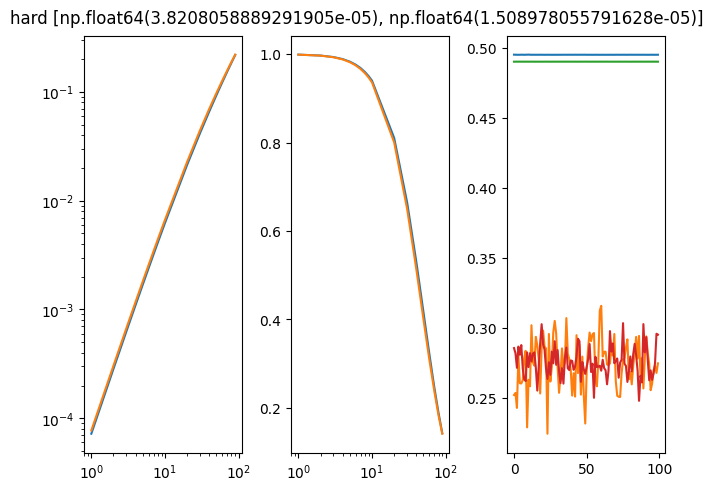

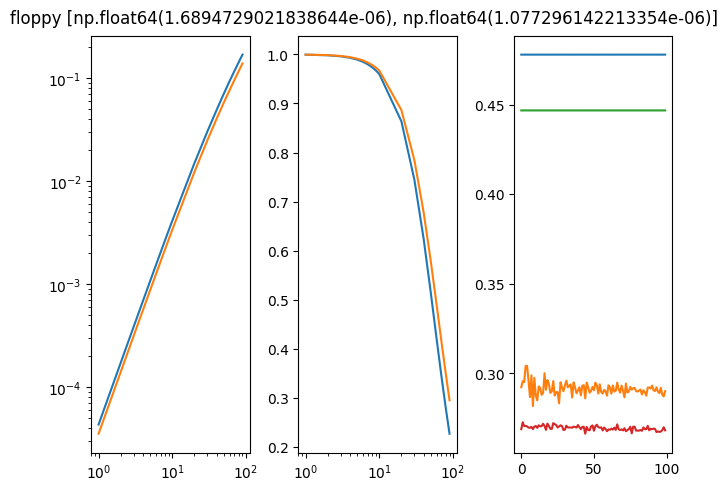

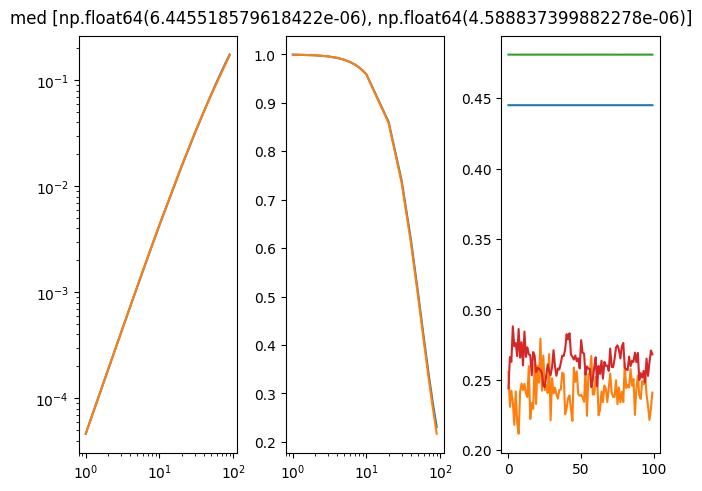

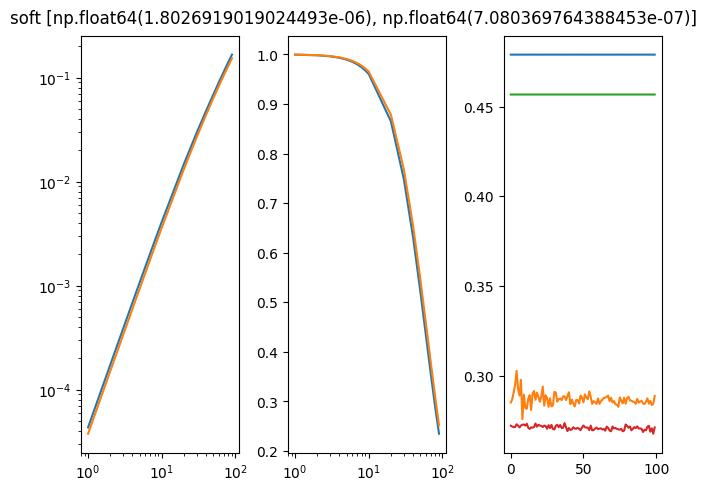

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from file_management import load_arrs
import os

path = '/home/mmccraw/dev/data/26-01-01/grant/dp-fragilitiy/version-3/'
for cfg_type in os.listdir(path):
    fig, ax = plt.subplots(1, 3, constrained_layout=True)
    kes = []
    flucs = []
    tes = []
    for phi_path in os.listdir(os.path.join(path, cfg_type)):
        data = load_arrs(os.path.join(path, cfg_type, phi_path, 'traj', 'data.h5'))
        isf = data['isf']
        msd = data['msd']
        t = data['t']
        flucs.append(np.std(data['ke'] + data['pe']) / np.mean(data['ke'] + data['pe']))
        ax[0].plot(t, msd)
        ax[1].plot(t, isf)
        ax[2].plot(data['ke'] + data['pe'])
        ax[2].plot(data['ke'])
    for a in ax[:2]:
        a.set_xscale('log')
    ax[0].set_yscale('log')
    plt.suptitle(cfg_type + ' ' + str(flucs))
    plt.show()